In [1]:
import os
import rasterio
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from rasterio.windows import Window
from rasterio.env import Env
from pathlib import Path
import pandas as pd
import numpy as np

2026-03-27 17:06:58.105421: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print(tf.__version__)
print(tf.sysconfig.get_build_info())

2.10.0
OrderedDict([('cpu_compiler', '/home/conda/feedstock_root/build_artifacts/tensorflow-split_1663206301846/_build_env/bin/x86_64-conda-linux-gnu-gcc'), ('cuda_compute_capabilities', ['sm_35', 'sm_50', 'sm_60', 'sm_62', 'sm_70', 'sm_72', 'sm_75', 'sm_80', 'sm_86', 'compute_86']), ('cuda_version', '11.2'), ('cudnn_version', '8'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False)])


In [3]:
input_data_dsm = '/home/ml_user/script/Training_cnn/src/data/gujarath_dsm_RGBZ.tif'
input_data_dtm = '/home/ml_user/script/Training_cnn/src/data/RGB_filled.tif'
# output_dtm_tif = '/home/ajai-krishna/work/GEO_AI/data/Training/dtm_patches'
# output_dsm_tif = '/home/ajai-krishna/work/GEO_AI/data/Training/dsm_patches'
model_output_dir = 'home/ml_user/script/Training_cnn/src/data/models' 

# output_trainin

In [4]:
with rasterio.open(input_data_dtm) as dtm_src:
    print(dtm_src.count)

4


In [5]:
def dsm_dtm_generator(
    dsm_path,
    dtm_path,
    patch=512,
    stride=64,
    batch_size=8
):
    import rasterio
    import numpy as np
    from rasterio.windows import Window

    with rasterio.open(dtm_path) as dtm_src, \
         rasterio.open(dsm_path) as dsm_src:

        H, W = dtm_src.height, dtm_src.width

        # ── Read full rasters for normalization ──
        dtmfull = dtm_src.read(4).astype(np.float32)
        dsmfull = dsm_src.read().astype(np.float32)
        
        dsm_rgb = dsmfull[:3]
        dsm_h   = dsmfull[3]

        # dtm_rgb = dtmfull[:3]
        dtm_h   = dtmfull

        # ── Clean ──
        dtmfull[(dtmfull < -50) | (dtmfull > 5000)] = np.nan
        dsmfull[(dsmfull < -50) | (dsmfull > 5000)] = np.nan

        # ── Stats ──
        dsm_min, dsm_max = np.nanmin(dsm_h), np.nanmax(dsm_h)
        dtm_min, dtm_max = np.nanmin(dtm_h), np.nanmax(dtm_h)


        print(f"DTM range: {dtm_min:.2f} → {dtm_max:.2f}")
        print(f"DSM range: {dsm_min:.2f} → {dsm_max:.2f}")

        # ── Patch coordinates ──
        coords = [
            (y, x)
            for y in range(0, H - patch + 1, stride)
            for x in range(0, W - patch + 1, stride)
        ]

        eps = 1e-6

        # ── Generator loop ──
        while True:
            np.random.shuffle(coords)

            X_batch, y_batch = [], []

            for i, (y, x) in enumerate(coords):

                window = Window(x, y, patch, patch)

                # ── Read patches ──
                dsm = dsm_src.read(window=window).astype(np.float32)     # (4,H,W)
                dtm = dtm_src.read(1,window=window).astype(np.float32)  # (H,W)


                dsm_rgb = dsm[:3]
                dsm_h   = dsm[3]

                # dtm_rgb = dtm[:3]
                dtm_h   = dtm

                
                # ── Clean ──
                dsm_h[(dsm_h < -50) | (dsm_h > 5000)] = np.nan
                dtm_h[(dtm_h < -50) | (dtm_h > 5000)] = np.nan

                # Replace NaN
                dsm_h = np.nan_to_num(dsm_h, nan=0.0)
                dtm_h = np.nan_to_num(dtm_h, nan=0.0)

                # ── Normalize ──
                dsm_rgb = dsm_rgb / 255.0
                # dtm_rgb = dtm_rgb / 255.0

                dsm_h = (dsm_h - dsm_min) / (dsm_max - dsm_min + eps)
                dtm_h = (dtm_h - dtm_min) / (dtm_max - dtm_min + eps)
                
                # Normalize DSM height
                X = dsm_h[..., np.newaxis]   # (H,W,1)
                y = dtm_h[..., np.newaxis]   # (H,W,1)


                # Clip
                X = np.clip(X, 0, 1)
                y = np.clip(y, 0, 1)

                X_batch.append(X)
                y_batch.append(y)

                if len(X_batch) == batch_size:
                    yield np.array(X_batch), np.array(y_batch)
                    X_batch, y_batch = [], []

In [6]:
def build_simple_cnn(input_shape=(512,512,1)):

    inputs = layers.Input(input_shape)

    # Feature extraction
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    # x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    # Downsample
    x = layers.MaxPooling2D()(x)

    # Bottleneck
    # x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    # Upsample
    x = layers.UpSampling2D()(x)

    # Output: 4 channels (RGB + height)
    outputs = layers.Conv2D(1, 1, activation='linear')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

In [7]:
import math
model = build_simple_cnn()
# model.summary()


gen = dsm_dtm_generator(
    dsm_path=input_data_dsm,
    dtm_path=input_data_dtm,
    patch=512,
    stride=64,
    batch_size=8
)

model.fit(
    gen,
    steps_per_epoch=200,
    epochs=15
)

2026-03-27 17:06:59.408995: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-27 17:06:59.432433: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-27 17:06:59.432980: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-27 17:06:59.433656: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

DTM range: -31.58 → 8.25
DSM range: -31.35 → 17.16
Epoch 1/15


2026-03-27 17:07:11.445517: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8907
2026-03-27 17:07:11.852779: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-27 17:07:11.866609: W tensorflow/core/kernels/gpu_utils.cc:70] Failed to check cudnn convolutions for out-of-bounds reads and writes with an error message: 'Failed to load in-memory CUBIN: CUDA_ERROR_INVALID_IMAGE: device kernel image is invalid'; skipping this check. This only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.
2026-03-27 17:07:11.989974: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


200/200 [==============================] - 18s 80ms/step - loss: 0.0864 - mae: 0.2346
Epoch 2/15
200/200 [==============================] - 16s 80ms/step - loss: 0.0035 - mae: 0.0443
Epoch 3/15
200/200 [==============================] - 16s 81ms/step - loss: 1.4589e-04 - mae: 0.0041
Epoch 4/15
200/200 [==============================] - 16s 80ms/step - loss: 5.4064e-05 - mae: 0.0020
Epoch 5/15
200/200 [==============================] - 16s 80ms/step - loss: 3.4782e-05 - mae: 0.0016
Epoch 6/15
200/200 [==============================] - 16s 81ms/step - loss: 3.2071e-05 - mae: 0.0015
Epoch 7/15
200/200 [==============================] - 16s 81ms/step - loss: 2.8172e-05 - mae: 0.0011
Epoch 8/15
200/200 [==============================] - 16s 81ms/step - loss: 2.5763e-05 - mae: 0.0010
Epoch 9/15
200/200 [==============================] - 16s 81ms/step - loss: 2.5785e-05 - mae: 0.0011
Epoch 10/15
200/200 [==============================] - 16s 82ms/step - loss: 2.6241e-05 - mae: 0.0010
Epoch 11

In [8]:
# ── Save entire model (recommended) ──
model.save("my_model.keras")          # Modern format
model.save("my_model.h5")             # Legacy HDF5 format

# ── Save only weights ──
model.save_weights("my_weights.h5")

# ── Load back ──
from tensorflow.keras.models import load_model
model = load_model("my_model.keras")

# from tensorflow.keras.models import load_model

# # Load saved model
# model = load_model('my_model.keras')
# print("Model loaded successfully")

In [9]:
X_batch, y_batch = next(gen)
print("\n===== BATCH STATS =====")
print(f"Batch X range: {X_batch.min():.4f} → {X_batch.max():.4f}")
print(f"Batch y range: {y_batch.min():.4f} → {y_batch.max():.4f}")

print(f"Batch X mean: {X_batch.mean():.4f}, std: {X_batch.std():.4f}")
print(f"Batch y mean: {y_batch.mean():.4f}, std: {y_batch.std():.4f}")
print("========================\n")



===== BATCH STATS =====
Batch X range: 0.2269 → 0.6463
Batch y range: 0.7929 → 1.0000
Batch X mean: 0.3908, std: 0.1642
Batch y mean: 0.7930, std: 0.0033



In [10]:
y_pred = model.predict(X_batch)

1/1 [==============================] - 0s 66ms/step


In [11]:
import rasterio
import numpy as np

with rasterio.open(input_data_dtm) as dtm_src, rasterio.open(input_data_dsm) as dsm_src:
    dtmfull = dtm_src.read(4).astype(np.float32)
    dsmfull = dsm_src.read(4).astype(np.float32)

dtmfull[(dtmfull < -50) | (dtmfull > 5000)] = np.nan
dsmfull[(dsmfull < -50 ) | (dsmfull > 5000)] = np.nan

dsm_min = np.nanmin(dsmfull)
dsm_max = np.nanmax(dsmfull)
dtm_min = np.nanmin(dtmfull)
dtm_max = np.nanmax(dtmfull)

print(dtm_min, dtm_max, dsm_min,dsm_max)

-31.575 8.247 -31.353 17.159


In [12]:
y_pred.shape

(8, 512, 512, 1)

In [13]:
y_true_rgb = (y_batch[..., :3] * 255).astype(np.uint8)
y_pred_rgb = (y_pred[..., :3] * 255).astype(np.uint8)

# Height channel: reverse min-max normalization
y_true_h = y_batch[..., 3:4] * (dtm_max - dtm_min) + dtm_min
y_pred_h = y_pred[..., 3:4] * (dtm_max - dtm_min) + dtm_min

In [14]:
print("X_batch:", X_batch.shape)
print("y_batch:", y_batch.shape)
print("y_pred:", y_pred.shape)

X_batch: (8, 512, 512, 1)
y_batch: (8, 512, 512, 1)
y_pred: (8, 512, 512, 1)


In [15]:
y_batch[..., 0][0]

array([[0.7929035, 0.7929035, 0.7929035, ..., 0.7929035, 0.7929035,
        0.7929035],
       [0.7929035, 0.7929035, 0.7929035, ..., 0.7929035, 0.7929035,
        0.7929035],
       [0.7929035, 0.7929035, 0.7929035, ..., 0.7929035, 0.7929035,
        0.7929035],
       ...,
       [0.7929035, 0.7929035, 0.7929035, ..., 0.7929035, 0.7929035,
        0.7929035],
       [0.7929035, 0.7929035, 0.7929035, ..., 0.7929035, 0.7929035,
        0.7929035],
       [0.7929035, 0.7929035, 0.7929035, ..., 0.7929035, 0.7929035,
        0.7929035]], dtype=float32)

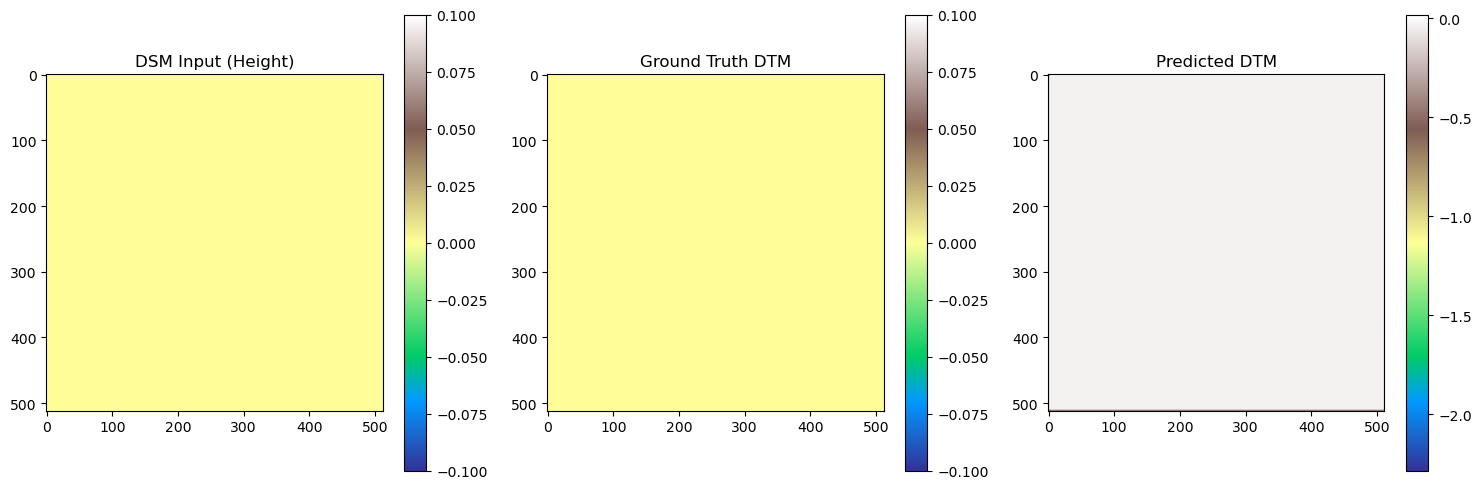

In [16]:
import matplotlib.pyplot as plt

# ── Denormalize ──
X_batch_h   = X_batch[..., 0] * (dsm_max - dsm_min) + dsm_min  # DSM height
y_true_denorm = y_batch[..., 0] * (dtm_max - dtm_min) + dtm_min  # (B, 256, 256)
y_pred_denorm = y_pred[..., 0] * (dtm_max - dtm_min) + dtm_min   # (B, 256, 256)

# ── Plot ──
idx = 0
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(X_batch_h[idx], cmap='terrain')
plt.title("DSM Input (Height)")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(y_true_denorm[idx], cmap='terrain')
plt.title("Ground Truth DTM")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(y_pred_denorm[idx], cmap='terrain')
plt.title("Predicted DTM")
plt.colorbar()

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import rasterio
from rasterio.windows import Window

patch  = 512
stride = 64
eps    = 1e-6

with rasterio.open(input_data_dsm) as dsm_src, \
     rasterio.open(input_data_dtm) as dtm_src:

    H, W = dsm_src.height, dsm_src.width

    # ── Accumulators for overlap averaging ──
    output = np.zeros((H, W), dtype=np.float32)
    counts = np.zeros((H, W), dtype=np.float32)

    coords = [
        (y, x)
        for y in range(0, H - patch + 1, stride)
        for x in range(0, W - patch + 1, stride)
    ]

    # ── Run in batches ──
    batch_size = 8
    for b_start in range(0, len(coords), batch_size):
        batch_coords = coords[b_start : b_start + batch_size]
        X_batch = []

        for y, x in batch_coords:
            dsm = dsm_src.read(window=Window(x, y, patch, patch)).astype(np.float32)
            dsm_rgb = np.clip(dsm[:3] / 255.0, 0, 1)
            dsm_h   = np.nan_to_num(dsm[3], nan=0.0)
            dsm_h   = np.clip((dsm_h - dsm_min) / (dsm_max - dsm_min + eps), 0, 1)
            X = np.stack([*dsm_rgb, dsm_h], axis=-1)  # (256, 256, 4)
            X_batch.append(X)

        X_batch = np.array(X_batch)                   # (B, 256, 256, 4)
        preds   = model.predict(X_batch, verbose=0)   # (B, 256, 256, 1)
        preds   = preds[..., 0]                        # (B, 256, 256)

        # ── Stitch back ──
        for pred, (y, x) in zip(preds, batch_coords):
            output[y:y+patch, x:x+patch] += pred
            counts[y:y+patch, x:x+patch] += 1

    # ── Average overlapping regions ──
    output = np.divide(output, counts, where=counts > 0)

    # ── Denormalize ──
    output_m = output * (dtm_max - dtm_min) + dtm_min  # back to metres

    # ── Save as GeoTiff ──
    profile = dtm_src.profile
    profile.update(count=1, dtype='float32')

    with rasterio.open("predicted_dtm.tif", "w", **profile) as dst:
        dst.write(output_m[np.newaxis, ...])  # (1, H, W)

print("Saved → predicted_dtm.tif")

Saved → predicted_dtm.tif
